# Customer Segmentation Analysis using K-Means Clustering

## Introduction

Customer segmentation is the process of dividing customers into groups based on similar characteristics or purchasing behaviours. By identifying these groups, businesses can design targeted marketing strategies, improve customer satisfaction, and increase sales.

In this project, customer segmentation is performed using the K-Means clustering algorithm. The analysis is based on customers' purchasing behaviour through Recency, Frequency, and Monetary (RFM) metrics. The resulting customer segments provide insights that can help businesses personalize marketing campaigns and allocate resources more effectively.

## Objective

The objective of this project is to segment customers into distinct groups based on their purchasing behaviour using K-Means clustering. The analysis aims to:

- Perform data cleaning and preprocessing.
- Calculate customer purchasing behaviour using RFM analysis.
- Standardize the selected features.
- Determine the optimal number of clusters using the Elbow Method.
- Apply K-Means clustering.
- Visualize customer segments.
- Profile each customer segment.
- Recommend marketing strategies for each segment.

In [4]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [5]:
#Load the dataset
df = pd.read_excel("C:/Users/USER/Documents/OIBSIP/DataAnalytics-L1-CustomerSegmentation/Online Retail.xlsx")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

5268

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
df[['Quantity','UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


## Data Quality Assessment

The descriptive statistics reveal several data quality issues that must be addressed before customer segmentation.

### Key Observations

- The `Quantity` column contains negative values, with a minimum of **-80,995**. These represent returned or cancelled orders and are not actual purchases.
- The `UnitPrice` column also contains negative values, with a minimum value of **-11,062.06**, which are invalid for customer spending analysis.
- There are missing values in the `CustomerID` column, making it impossible to assign some transactions to specific customers.
- The dataset also contains duplicate records that could distort customer purchase frequency and total spending.

In [14]:
#Data Cleaning
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
# Check remaining missing values
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicates
df.duplicated().sum()

0

In [16]:
# Keep only positive quantities
df = df[df['Quantity'] > 0]
df['Quantity'].describe()
# Keep only positive prices
df = df[df['UnitPrice'] > 0]
df['UnitPrice'].describe()

count    392692.000000
mean          3.125914
std          22.241836
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [17]:
df.shape

df.info()

df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


## Data Cleaning Summary

The dataset was successfully cleaned and prepared for customer segmentation.

The following preprocessing steps were performed:

- Removed transactions with missing **CustomerID** values.
- Removed duplicate records.
- Removed returned or cancelled transactions (negative quantities).
- Removed transactions with zero or negative unit prices.

After cleaning, the dataset contains **392,692 valid transactions** with no missing values in the variables required for customer segmentation.

In [19]:
# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Display first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
# RFM Analysis

# Create reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [21]:
# Create the RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename the columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display the first five rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Analysis

To measure customer purchasing behaviour, an RFM (Recency, Frequency, Monetary) table was created.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique purchase transactions made by each customer.
- **Monetary:** Total amount spent by each customer across all purchases.

These three features form the basis for customer segmentation using the K-Means clustering algorithm.

In [23]:
# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Display first five rows
rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [24]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform the data
rfm_scaled = scaler.fit_transform(rfm_features)

In [25]:
# Convert scaled data to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features.columns,
    index=rfm_features.index
)

# Display first five rows
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


### Observation

The RFM features were successfully standardized using **StandardScaler**.

After scaling:

- The features are centered around a mean of approximately **0**.
- Positive values indicate customers above the average for a feature.
- Negative values indicate customers below the average.
- Standardization ensures that **Recency**, **Frequency**, and **Monetary** contribute equally during clustering, preventing features with larger numerical values from dominating the model.

In [27]:
# Elbow Method
# Determine the optimal number of clusters using the Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

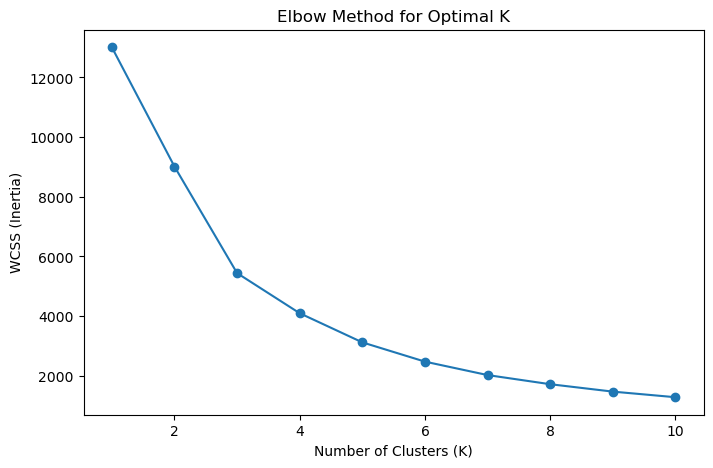

In [28]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')

plt.show()

In [29]:
n_clusters = 4

### Observation

The Elbow Method indicates that **4 clusters** is the optimal number of customer segments.

The WCSS decreases sharply between K = 1 and K = 4, after which the rate of improvement slows considerably. Therefore, **K = 4** was selected as it provides a good balance between model simplicity and clustering performance.

In [31]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model and predict cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first five rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [32]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


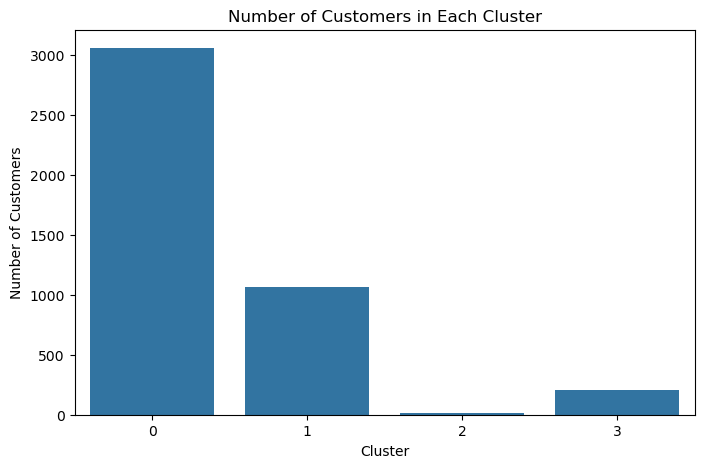

In [34]:
# Count customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

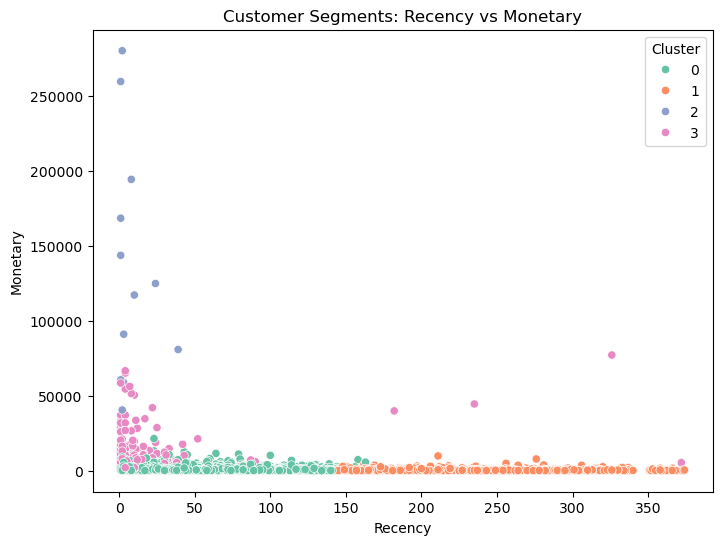

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.show()

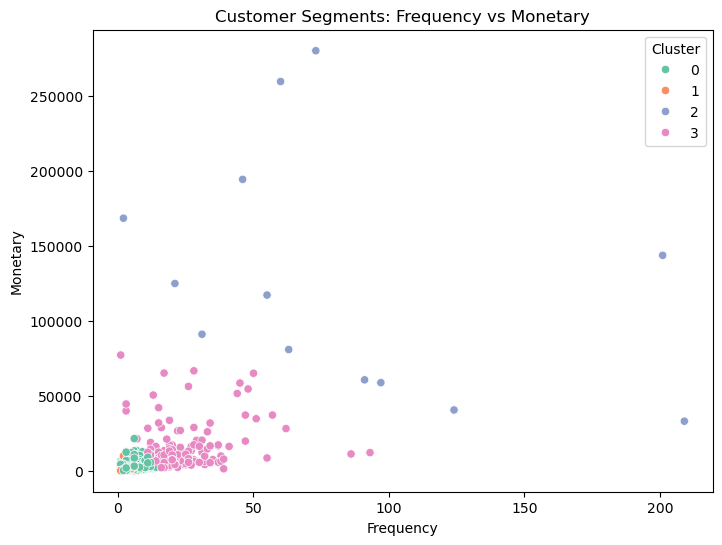

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

## Cluster Profiling

The K-Means algorithm grouped customers into four distinct segments based on their purchasing behaviour.

### Cluster 0 – Regular Customers
- Moderate recency, moderate purchase frequency, and moderate spending.
- These customers purchase occasionally and represent a stable customer base.
- Marketing Action: Promote loyalty programs and personalized product recommendations to encourage more frequent purchases.

### Cluster 1 – Inactive / At-Risk Customers
- High recency, low purchase frequency, and low spending.
- These customers have not purchased recently and are at risk of churn.
- Marketing Action: Implement re-engagement campaigns, discounts, and promotional emails to encourage them to return.

### Cluster 2 – VIP / High-Value Customers
- Very low recency, extremely high purchase frequency, and exceptionally high spending.
- These customers are the company's most valuable customers.
- Marketing Action: Provide exclusive offers, premium customer service, loyalty rewards, and early access to new products.

### Cluster 3 – Loyal Customers
- Low recency, high purchase frequency, and high spending.
- These customers consistently purchase and contribute significantly to revenue.
- Marketing Action: Maintain engagement through personalized recommendations, loyalty incentives, and cross-selling opportunities.

# Business Insights and Recommendations

Based on the customer segmentation analysis, the following recommendations are proposed:

1. **Retain VIP Customers**
   - Provide exclusive discounts, premium support, and loyalty rewards to maintain long-term relationships with high-value customers.

2. **Re-engage At-Risk Customers**
   - Launch targeted email campaigns, promotional offers, and personalized discounts to encourage inactive customers to return.

3. **Increase the Value of Regular Customers**
   - Introduce personalized product recommendations and loyalty programs to encourage more frequent purchases and increase customer lifetime value.

4. **Reward Loyal Customers**
   - Recognize loyal customers through membership benefits, referral programs, and early access to promotions to strengthen customer retention.

Overall, customer segmentation enables businesses to design targeted marketing strategies, improve customer satisfaction, and maximize revenue by addressing the needs of different customer groups.